# Reconstruction probe

JEPA has no decoder by design. To *see* what a latent encodes, train a small decoder on the frozen encoder's outputs: frozen encoder -> z -> trained deconv -> frame. The encoder never updates; only the decoder learns to invert z back to pixels.

Then visualize, per transition:
- `frame_t` and its reconstruction from `z_t` (what the latent kept)
- the true next frame and the model's predicted next frame (decode the predictor's `z_{t+1}`)

The predicted-next column makes heading aliasing visible: when the encoder confuses a heading with its 180-degree opposite, the predicted triangle points the wrong way.

> To generate `eval/reconstruct.py`, run from `PHYSWM/`:
> ```
> jupyter nbconvert --to python eval/reconstruct.ipynb
> ```

## Path setup

In [7]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from config import DATA_PATH, CKPT_PATH, SEED, REPORT_DIR, GRID_SIZE, LATENT_DIM, ENCODER_CHANNELS

## Imports

In [8]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from typing import Optional, Union

try:
    from models.jepa import JEPA
    from models.dataset import make_dataloaders
    from sim.render import render_frame
    from eval.probe import (
        extract_latents, make_linear_probe, train_probe,
        state_to_target, target_to_state,
    )
except ImportError:
    from jepa import JEPA
    from dataset import make_dataloaders
    from render import render_frame
    from probe import (
        extract_latents, make_linear_probe, train_probe,
        state_to_target, target_to_state,
    )

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def _sample_batch(ds, n: int, seed: int = 0) -> dict:
    """Stack n random samples from a dataset into one batch dict.

    Random sampling matters: consecutive transitions in the loader come from the
    same episode (near-identical pose), so taking the first n would show n copies
    of one frame. This pulls n genuinely different transitions.
    """
    rng     = np.random.default_rng(seed)
    idx     = rng.choice(len(ds), size=min(n, len(ds)), replace=False)
    samples = [ds[int(i)] for i in idx]
    return {k: torch.stack([s[k] for s in samples]) for k in samples[0]}

## Decoder

Mirror of the encoder. `latent -> linear -> (C, h0, w0) -> ConvTranspose x len(channels) -> (1, H, W)`. Each transpose (kernel 4, stride 2, pad 1) exactly doubles the spatial size, so `grid_size` must be divisible by `2 ** len(channels)` (8 for the default 3-stage encoder: 40, 64, 128 all qualify; 84 would not).

In [9]:
class Decoder(nn.Module):
    """Latent z -> reconstructed frame logits, mirroring the encoder.

    Parameters
    ----------
    grid_size : int
        Output frame side length.
    latent_dim : int
        Input latent size.
    channels : tuple of int
        The encoder's conv channels. The decoder upsamples through them reversed.

    Defaults pull from config.py.
    """

    def __init__(
        self,
        grid_size: int = GRID_SIZE,
        latent_dim: int = LATENT_DIM,
        channels: tuple = ENCODER_CHANNELS,
    ):
        super().__init__()
        factor = 2 ** len(channels)
        if grid_size % factor != 0:
            raise ValueError(f"grid_size {grid_size} must be divisible by {factor}")
        self.c0 = channels[-1]
        self.h0 = grid_size // factor
        self.fc = nn.Linear(latent_dim, self.c0 * self.h0 * self.h0)

        rev  = list(channels[::-1])     # e.g. [128, 64, 32]
        outs = rev[1:] + [1]            # e.g. [64, 32, 1]
        layers = []
        c_in = rev[0]
        for i, c_out in enumerate(outs):
            layers.append(nn.ConvTranspose2d(c_in, c_out, kernel_size=4, stride=2, padding=1))
            if i < len(outs) - 1:
                layers.append(nn.ReLU(inplace=True))
            c_in = c_out
        self.deconv = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """z (B, latent_dim) -> frame logits (B, 1, H, W)."""
        x = self.fc(z).view(-1, self.c0, self.h0, self.h0)
        return self.deconv(x)

## Train the decoder

Frozen encoder (no_grad + eval), only the decoder learns. Frames are binary, so BCE-with-logits. This measures what the latent *can* be inverted to, not what the model was trained for.

In [10]:
def train_decoder(
    model: JEPA,
    dl,
    epochs: int = 5,
    lr: float = 1e-3,
    device: Optional[str] = None,
) -> Decoder:
    """Fit a decoder on the frozen encoder's latents.

    Parameters
    ----------
    model : JEPA
        Trained model. Its encoder is frozen here.
    dl : DataLoader
        Frames are enough (return_state not required).
    epochs, lr : training hyperparameters.
    device : str, optional.

    Returns
    -------
    Decoder, trained, on device.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device).eval()
    decoder = Decoder(grid_size=dl.dataset.grid_size, latent_dim=model.latent_dim).to(device).train()
    opt = torch.optim.Adam(decoder.parameters(), lr=lr)
    bce = nn.BCEWithLogitsLoss()
    for epoch in range(epochs):
        running = 0.0
        for batch in dl:
            frame = batch["frame"].to(device)
            with torch.no_grad():
                z = model.encode(frame)
            loss = bce(decoder(z), frame)
            opt.zero_grad()
            loss.backward()
            opt.step()
            running += loss.item()
        print(f"epoch {epoch+1}/{epochs}  bce {running / len(dl):.4f}")
    return decoder

## Visualize reconstructions

Four columns per row: `frame_t`, its reconstruction `recon(z_t)`, the true next frame, and the predicted next frame (decode `predict(z_t, action)`). The pred-next column is where heading aliasing shows: a 180-flipped triangle means the encoder confused the heading with its opposite. If the loader has `return_state=True`, each row is labeled with the true heading of `frame_t`.

In [11]:
@torch.no_grad()
def plot_reconstructions(
    model: JEPA,
    decoder: Decoder,
    dl,
    n: int = 6,
    seed: int = 0,
    device: Optional[str] = None,
    save_to: Optional[Union[str, Path]] = None,
):
    """Show frame_t, its reconstruction, the true next frame, and the predicted next.

    Grayscale on purpose: the decoder outputs per-pixel probabilities, so blur =
    the encoder/predictor is uncertain there. Thresholding to binary would hide
    that. n random transitions (not the first n, which are one episode).

    Returns
    -------
    matplotlib Figure.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device).eval()
    decoder.to(device).eval()

    batch  = _sample_batch(dl.dataset, n, seed=seed)
    frame  = batch["frame"].to(device)
    action = batch["action"].to(device)
    nxt    = batch["next_frame"][:n].to(device)

    z         = model.encode(frame)
    recon     = torch.sigmoid(decoder(z))                         # recon of frame_t
    pred_next = torch.sigmoid(decoder(model.predict(z, action)))  # predicted frame_{t+1}

    imgs   = [t.cpu() for t in (frame, recon, nxt, pred_next)]
    thetas = batch["state"][:n, 2] if "state" in batch else None
    cols   = ["frame_t", "recon(z_t)", "true next", "pred next"]

    fig, axes = plt.subplots(n, 4, figsize=(8, 2 * n))
    for i in range(n):
        for j in range(4):
            ax = axes[i, j]
            ax.imshow(imgs[j][i, 0], cmap="gray", interpolation="nearest", vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
            if i == 0:
                ax.set_title(cols[j], fontsize=10)
        if thetas is not None:
            axes[i, 0].set_ylabel(f"{np.degrees(thetas[i].item()):.0f} deg", fontsize=9)
    fig.tight_layout()
    if save_to is not None:
        fig.savefig(save_to, dpi=110, bbox_inches="tight")
        print(f"wrote {save_to}")
    return fig

## Render-based reconstruction (probe + simulator)

The structured alternative to the deconv decoder. Instead of learning pixels, decode the latent to `(x, y, theta)` with a linear probe, then draw the frame with the known `render_frame`. Zero learned pixel parameters, so every pixel is explained by the 3-number pose.

Trade-off vs the deconv decoder: this always draws a crisp triangle at the predicted pose (no blur, so it hides uncertainty), but a heading flip is unmistakable, the triangle points the wrong way. Use both: deconv shows what the latent kept (with uncertainty), this shows the pose the latent implies.

In [12]:
def plot_pose_reconstructions(
    model: JEPA,
    dl,
    probe_epochs: int = 40,
    n: int = 6,
    seed: int = 0,
    device: Optional[str] = None,
    save_to: Optional[Union[str, Path]] = None,
):
    """Render-based reconstruction: z -> probe -> (x, y, theta) -> render_frame.

    Trains a linear probe on the frozen latents, then renders a clean triangle at
    the probe's predicted pose using the known simulator renderer. Every pixel is
    explained by 3 numbers, so a heading flip shows as a flipped triangle.

    Columns: frame_t | render(pose of z_t) | true next | render(pose of predict(z_t, a)).
    Row label is the TRUE heading of frame_t; compare it to the rendered triangle.

    Parameters
    ----------
    model : JEPA
    dl : DataLoader
        Must have return_state=True.
    probe_epochs : int
        Epochs for the linear probe used to read out pose.
    n, seed, device, save_to : as elsewhere.

    Returns
    -------
    matplotlib Figure.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device).eval()
    grid = dl.dataset.grid_size

    # fit a linear probe on the frozen latents (this is the only learned part)
    Z, S  = extract_latents(model, dl, device)
    probe = make_linear_probe(Z.shape[1])
    probe = train_probe(probe, Z, state_to_target(S), epochs=probe_epochs, device=device)
    probe.eval()

    batch  = _sample_batch(dl.dataset, n, seed=seed)
    frame  = batch["frame"].to(device)
    action = batch["action"].to(device)
    nxt    = batch["next_frame"]
    true_theta = batch["state"][:, 2].numpy()

    with torch.no_grad():
        z         = model.encode(frame)
        pose_t    = target_to_state(probe(z)).cpu().numpy()              # pose from z_t
        pose_next = target_to_state(probe(model.predict(z, action))).cpu().numpy()

    cols = ["frame_t", "render(pose z_t)", "true next", "render(pred next)"]
    fig, axes = plt.subplots(n, 4, figsize=(8, 2 * n))
    for i in range(n):
        renders = [
            frame[i, 0].cpu().numpy(),
            render_frame(pose_t[i], grid_size=grid),
            nxt[i, 0].numpy(),
            render_frame(pose_next[i], grid_size=grid),
        ]
        for j in range(4):
            ax = axes[i, j]
            ax.imshow(renders[j], cmap="gray", interpolation="nearest", vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
            if i == 0:
                ax.set_title(cols[j], fontsize=10)
        axes[i, 0].set_ylabel(f"{np.degrees(true_theta[i]):.0f} deg", fontsize=9)
    fig.tight_layout()
    if save_to is not None:
        fig.savefig(save_to, dpi=110, bbox_inches="tight")
        print(f"wrote {save_to}")
    return fig

## Run it

Load the run's checkpoint, train a decoder on the frozen encoder, and plot reconstructions for held-out transitions. Saves to `results/<RUN>/reconstructions.png`.

epoch 1/5  bce 0.0156
epoch 2/5  bce 0.0042
epoch 3/5  bce 0.0034
epoch 4/5  bce 0.0029
epoch 5/5  bce 0.0026
wrote c:\Users\donov\OneDrive\Desktop\PHYSWM\results\run01_40x40\reconstructions.png
wrote c:\Users\donov\OneDrive\Desktop\PHYSWM\results\run01_40x40\pose_reconstructions.png


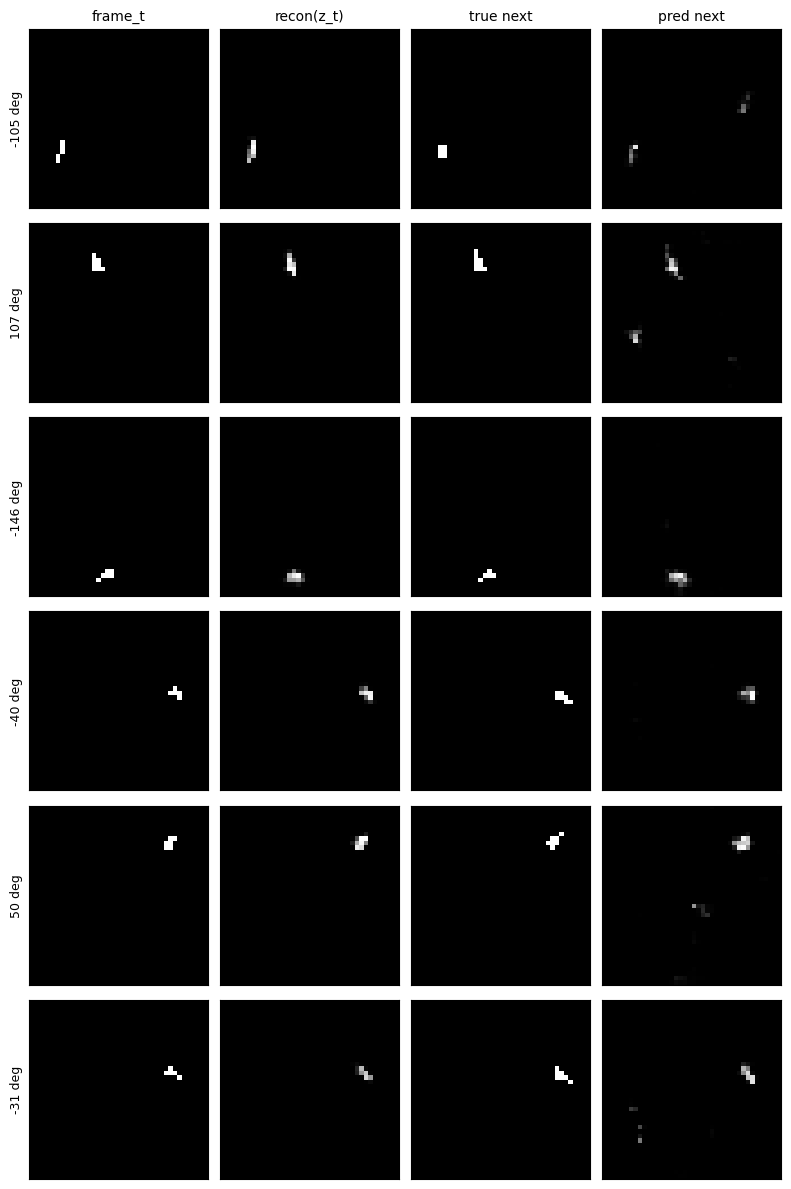

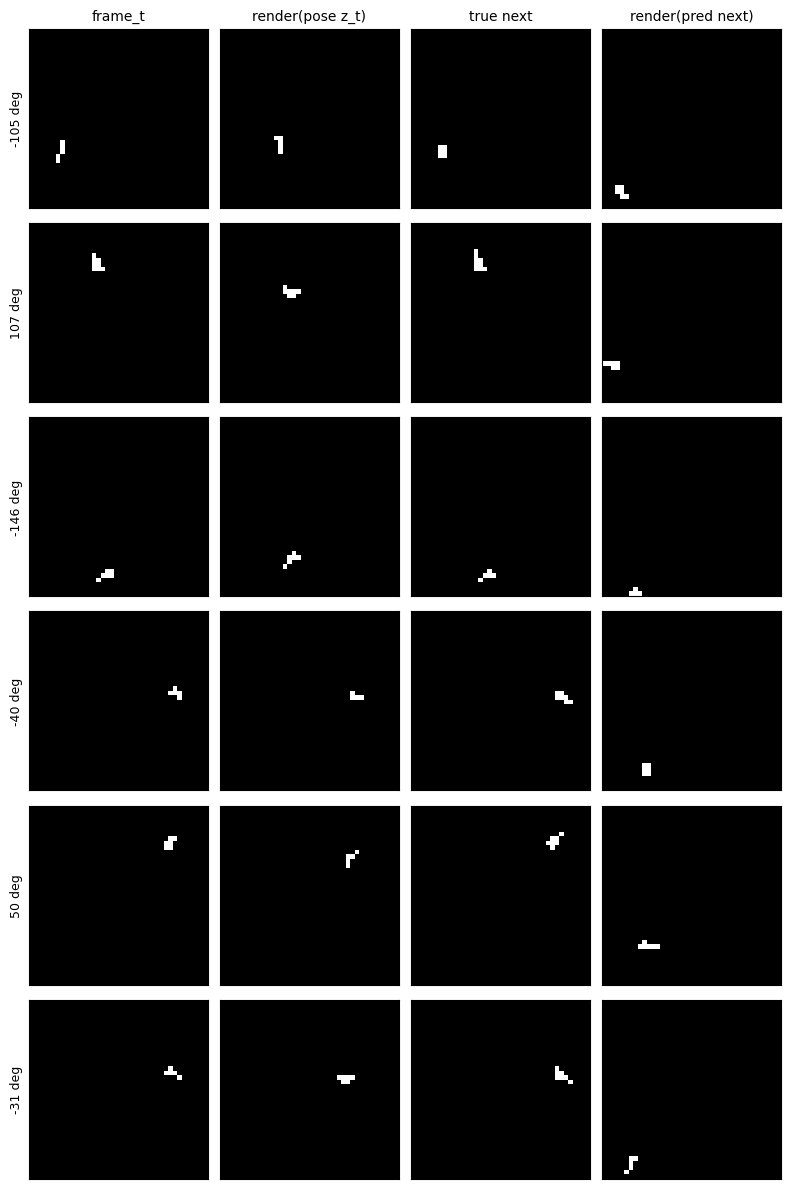

In [13]:
if __name__ == "__main__":
    if CKPT_PATH.exists():
        train_dl, val_dl = make_dataloaders(DATA_PATH, seed=SEED, return_state=True)
        model = JEPA(grid_size=train_dl.dataset.grid_size, latent_dim=LATENT_DIM)
        model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

        # learned deconv decoder: honest mirror of the latent (shows blur/uncertainty)
        decoder = train_decoder(model, train_dl, epochs=5, device=DEVICE)
        plot_reconstructions(model, decoder, val_dl, n=6, device=DEVICE,
                             save_to=REPORT_DIR / "reconstructions.png")

        # render-based: decode to pose, draw with the simulator (heading flips visible)
        plot_pose_reconstructions(model, val_dl, n=6, device=DEVICE,
                                  save_to=REPORT_DIR / "pose_reconstructions.png")
        plt.show()
    else:
        print(f"no checkpoint at {CKPT_PATH} - train one first (pipeline.ipynb)")